# ABW Step-by-Step Debug Notebook

This notebook is for **finer control and debugging** and makes the boundary explicit:
- BayesFlow: amortizer setup + training
- ABW: PSIS/MCMC workflow orchestration and diagnostics

Instead of calling `workflow.run(...)` end-to-end, it runs each step manually.


Requirements (example):
```bash
export KERAS_BACKEND=jax
pip install -e '.[bayesflow,pymc,blackjax]'
pip install pymc-extras
# optional fallback backend
pip install 'tensorflow-probability[jax]'
```


In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import bayesflow as bf
import matplotlib.pyplot as plt

from amortized_bayesian_workflow import (
    ArtifactLayout,
    WorkflowConfig,
    WorkflowRunner,
)
from amortized_bayesian_workflow.approximators import (
    BayesFlowAmortizedPosterior,
)
from amortized_bayesian_workflow.backends import SamplerRequest
from amortized_bayesian_workflow.psis import (
    compute_psis,
    resample_with_weights,
)

print(f"BayesFlow version: {bf.__version__}")

INFO:2026-03-18 20:57:56,234:jax._src.xla_bridge:834: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/Users/lichengk/.miniforge3/envs/abw/bin/../lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file)
INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/Users/lichengk/.miniforge3/envs/abw/bin/../lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file)
INFO:bayesflow:Using backend 'jax'
/Users/lichengk/.miniforge3/envs/abw/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywi

BayesFlow version: 2.0.8


## 1. Build task and BayesFlow amortizer


In [3]:
from amortized_bayesian_workflow.tasks.examples import (
    PsychometricTask,
    GeneralizedExtremeValue,
)

task = PsychometricTask()
task = GeneralizedExtremeValue()
task.var_dims


INFO:arviz.preview:arviz_base not installed
INFO:arviz.preview:arviz_stats not installed
INFO:arviz.preview:arviz_plots not installed
/Users/lichengk/.miniforge3/envs/abw/lib/python3.11/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


OrderedDict([('mu', 1), ('sigma', 1), ('xi', 1)])

In [4]:
test_sims = task.simulate_prior_predictive(10000)

INFO:amortized_bayesian_workflow.tasks.pymc_task:Simulating from PyMC model...
INFO:pymc.sampling.forward:Sampling: [gev, mu, sigma, xi]
INFO:amortized_bayesian_workflow.tasks.pymc_task:Transforming prior samples to unconstrained space.


In [5]:
np.allclose(
    task.transform_to_unconstrained_space(
        task.transform_to_constrained_space(test_sims["parameters"])
    ),
    test_sims["parameters"],
)

True

In [6]:
config = WorkflowConfig(
    num_train_simulations=2_000,
    num_validation_simulations=500,
    num_amortized_draws=2_000,
    batch_size=128,
    epochs=5,
    parallel_mode="none",
    mcmc_backend="blackjax_nuts",
    mcmc_warmup=1000,
    mcmc_num_samples=1000,
    seed=2026,
)

In [7]:
from pathlib import Path

layout = ArtifactLayout(
    root=Path("./artifacts"),
    task_name=task.task_name,
)
layout.ensure()

ArtifactLayout(root=PosixPath('artifacts'), task_name='GeneralizedExtremeValue', run_name='default')

In [8]:
from bayesflow.workflows import BasicWorkflow
from bayesflow import OfflineDataset
from amortized_bayesian_workflow.approximators import (
    BayesFlowAmortizedPosterior,
)

adapter = bf.ContinuousApproximator.build_adapter(
    inference_variables=["parameters"],
    summary_variables=["observables"],
)
inference_network = bf.networks.CouplingFlow()
summary_network = bf.networks.DeepSet()

basic_amortized_workflow = BasicWorkflow(
    adapter=adapter,
    inference_network=inference_network,
    summary_network=summary_network,
    checkpoint_filepath=layout.models_dir / "training_checkpoint.pt",
)

train_sims = task.simulate_prior_predictive(
    config.num_train_simulations, seed=config.seed
)
val_sims = task.simulate_prior_predictive(
    config.num_validation_simulations, seed=config.seed + 1
)

history = basic_amortized_workflow.fit_offline(
    data=train_sims,
    validation_data=val_sims,
    epochs=config.epochs,
    batch_size=config.batch_size,
)

# Wrap the trained approximator and cache training summaries for Mahalanobis calibration.
approximator = BayesFlowAmortizedPosterior(
    basic_amortized_workflow.approximator
)
approximator.store_training_summaries(train_sims["observables"])
approximator.training_summaries.shape


Existing checkpoints can _not_ be restored/loaded using this workflow. Upon refitting, the checkpoints will be overwritten. To load the stored approximator from the checkpoint, use approximator = keras.saving.load_model(...)
INFO:amortized_bayesian_workflow.tasks.pymc_task:Simulating from PyMC model...
INFO:pymc.sampling.forward:Sampling: [gev, mu, sigma, xi]
INFO:amortized_bayesian_workflow.tasks.pymc_task:Transforming prior samples to unconstrained space.
INFO:amortized_bayesian_workflow.tasks.pymc_task:Simulating from PyMC model...
INFO:pymc.sampling.forward:Sampling: [gev, mu, sigma, xi]
INFO:amortized_bayesian_workflow.tasks.pymc_task:Transforming prior samples to unconstrained space.
INFO:bayesflow:Fitting on dataset instance of OfflineDataset.
INFO:bayesflow:Building on a test batch.


Epoch 1/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 11s 448ms/step - loss: 4.2477 - val_loss: 4.4474
Epoch 2/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - loss: 4.2677 - val_loss: 4.4048
Epoch 3/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - loss: 4.2346 - val_loss: 4.2813
Epoch 4/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - loss: 4.1053 - val_loss: 4.0665
Epoch 5/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - loss: 4.0051 - val_loss: 4.0909


INFO:bayesflow:Training completed in 20.65 seconds.
INFO:bayesflow:Training is now finished.
            You can find the trained approximator at 'artifacts/GeneralizedExtremeValue/default/models/training_checkpoint.pt/model.model.keras'.
            To load it, use approximator = keras.saving.load_model(...).


(2000, 16)

In [9]:
approximator.save(layout.models_dir)
approximator.load(layout.models_dir)

BayesFlowAmortizedPosterior(approximator=<ContinuousApproximator name=continuous_approximator, built=True>, observable_key='observables')

## 2. Build the InferenceRunner

With the amortizer trained and training summaries cached, construct the `WorkflowRunner`.
The runner will use the pre-computed `training_summaries` directly for Mahalanobis
calibration — no re-simulation needed.


In [10]:
runner = WorkflowRunner(task=task, approximator=approximator, config=config)
# Mahalanobis reference is auto-calibrated from approximator.training_summaries
# on the first call to runner.run() / _ensure_mahalanobis_reference().
# You can also trigger it explicitly:
runner._calibrate_mahalanobis_reference()
runner._mahalanobis_reference

In [ ]:
runner.approximator


BayesFlowAmortizedPosterior(approximator=<ContinuousApproximator name=continuous_approximator, built=False>, adapter_kwargs={}, observable_key='observables')

## 3. Amortized posterior draws (manual)


In [11]:
observation = task.simulate_prior_predictive(1, seed=config.seed + 42)[
    "observables"
][0]
amortized = approximator.sample_and_log_prob(
    observation, num_samples=config.num_amortized_draws, seed=config.seed
)
q_samples = amortized.samples
log_q = amortized.log_prob
q_samples.shape, log_q.shape


INFO:amortized_bayesian_workflow.tasks.pymc_task:Simulating from PyMC model...
INFO:pymc.sampling.forward:Sampling: [gev, mu, sigma, xi]
INFO:amortized_bayesian_workflow.tasks.pymc_task:Transforming prior samples to unconstrained space.
Sampling: 100%|██████████| 1/1 [00:01<00:00,  1.89s/batch]


((2000, 3), (2000,))

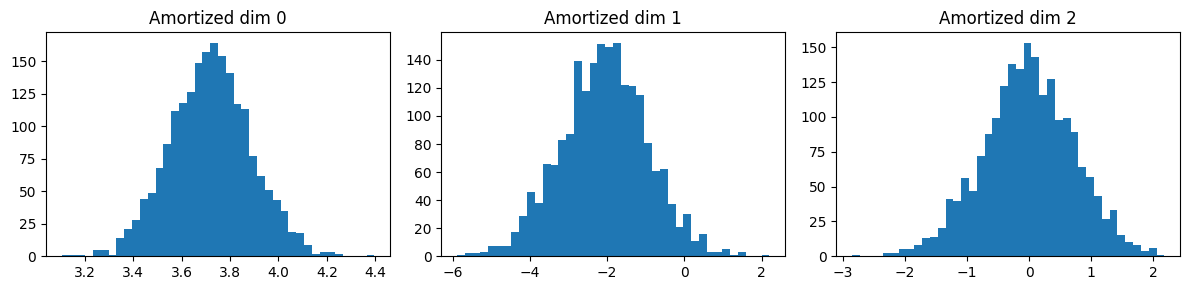

In [12]:
fig, ax = plt.subplots(
    1, q_samples.shape[1], figsize=(4 * q_samples.shape[1], 3)
)
ax = np.atleast_1d(ax)
for i in range(q_samples.shape[1]):
    ax[i].hist(q_samples[:, i], bins=40)
    ax[i].set_title(f"Amortized dim {i}")
plt.tight_layout()


## 4. Mahalanobis-distance diagnostic (observation-level)

A simple practical OOD-style diagnostic is to compare the observed dataset to prior-predictive simulated observations using Mahalanobis distance on flattened observables.

This is not the only possible diagnostic, but it is often useful before PSIS/MCMC.


In [14]:
# Build a Mahalanobis reference from prior-predictive observables
from amortized_bayesian_workflow.diagnostics import MahalanobisReference

ref = task.simulate_prior_predictive(1000, seed=config.seed + 99)
X_ref = ref["observables"]
x_obs = np.asarray(observation)[None, :]
# Fit the reference (the library uses the sqrt Mahalanobis distance)
mref = MahalanobisReference.from_training_summaries(X_ref)
# Per-observation Mahalanobis statistic (sqrt distance)
mahalanobis = mref.statistic(x_obs[0])
mahalanobis
# Optional: empirical cutoff at alpha=0.05
mref.threshold(alpha=0.05)

INFO:amortized_bayesian_workflow.tasks.pymc_task:Simulating from PyMC model...
INFO:pymc.sampling.forward:Sampling: [gev, mu, sigma, xi]
INFO:amortized_bayesian_workflow.tasks.pymc_task:Transforming prior samples to unconstrained space.


15.579501033251933

In [15]:
# Compare against the prior-predictive reference distribution of Mahalanobis distances
# Use the already-fitted MahalanobisReference: its `train_statistics` are sqrt distances
ref_md = mref.train_statistics
quantiles = np.quantile(ref_md, [0.5, 0.9, 0.95, 0.99])
quantiles, mahalanobis, mref.threshold(alpha=0.05)


(array([ 5.3773335 , 12.50896505, 15.57950103, 22.30732511]),
 7.729336847725297,
 15.579501033251933)

## 5. PSIS diagnostics (manual)

Compute the target posterior log density for amortized samples, then compare to amortized log-proposal density with PSIS.


In [16]:
log_post_vec = task.vectorized_log_posterior_fn(observation)
log_post_single = task.single_log_posterior_fn(observation)
log_target = log_post_vec(q_samples)
psis = compute_psis(log_target=log_target, log_proposal=log_q)
psis.pareto_k, psis.ess


AttributeError: 'GeneralizedExtremeValue' object has no attribute 'vectorized_log_posterior_fn'

In [ ]:
posterior_draws_psis = resample_with_weights(
    q_samples, psis.normalized_weights, num_draws=1000, seed=config.seed + 1
)
posterior_draws_psis.shape


## 6. Manual MCMC refinement (if needed)

If `pareto_k` is high (or if you want to force MCMC), call the backend directly.


In [ ]:
from amortized_bayesian_workflow.backends import get_backend

backend = get_backend(config.mcmc_backend)
top_k = 4
init_idx = np.argsort(-psis.smoothed_log_weights)[:top_k]
mcmc_result = backend.run(
    SamplerRequest(
        initial_positions=q_samples[init_idx],
        log_prob_fn=log_post_vec,
        single_log_prob_fn=log_post_single,
        num_warmup=200,  # use larger values in real runs
        num_samples=200,  # use larger values in real runs
        seed=config.seed + 2,
        options={"num_superchains": top_k},
    )
)
mcmc_result.backend, mcmc_result.draws.shape, mcmc_result.diagnostics


In [ ]:
posterior_draws_mcmc = mcmc_result.draws.reshape(
    -1, mcmc_result.draws.shape[-1]
)
posterior_draws_mcmc.shape


## 7. Compare with end-to-end workflow.run(...)

Once manual debugging looks good, switch back to the simpler high-level API.


In [ ]:
report = runner.run([observation])
report.summary_table()


In [ ]:
report.results[0].status, report.results[0].error
